In [1]:
import time

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3 import DQN
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt


# Question 1

In [2]:
!pip install swig


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [3]:
!pip install gymnasium


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [4]:
!pip install box2d


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [5]:
!pip install pygame


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [6]:
!pip install renderlab


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


# Question 2

Every gymnasium environment consists of 3 basic functions: step, reset, render.

### reset()

Resets the environment to its initial state and returns the initial observation. This function should be called at the beginning of each episode before taking any actions. It returns a tuple containing:
- observation: The initial state of the environment
- info: A dictionary with additional information

### step(action)

Executes one step in the environment using the given action. This is the main function for interaction with the environment. It returns a tuple containing:
- observation: The new state after taking the action
- reward: The reward received for taking the action
- terminated: Boolean indicating if the episode ended (goal reached or failure)
- truncated: Boolean indicating if the episode was cut short (e.g., time limit)
- info: A dictionary with additional information

### render()

Renders the current state of the environment for visualization. The render mode is specified when creating the environment. Common modes include:
- "human": Opens a window to display the environment
- "rgb_array": Returns an RGB array of the current frame for video recording

# Question 3

## LunarLander-v3 environment description

The goal is to land a spacecraft on a landing pad located at coordinates (0, 0). The lander starts at the top center of the screen with a random initial force applied.

### Observation Space

The observation is an 8-dimensional vector containing:
1. x position (horizontal)
2. y position (vertical)
3. x velocity (horizontal speed)
4. y velocity (vertical speed)
5. angle (lander orientation)
6. angular velocity (rotation speed)
7. left leg contact (1 if touching ground, 0 otherwise)
8. right leg contact (1 if touching ground, 0 otherwise)

Type: Box(-inf, inf, (8,), float32)

### Action Space

The action space is discrete with 4 possible actions:
- 0: Do nothing
- 1: Fire left orientation engine
- 2: Fire main engine (bottom)
- 3: Fire right orientation engine

Type: Discrete(4)

### Reward Function

The reward is computed based on several factors:
- Moving toward the landing pad increases reward
- Moving away from the landing pad decreases reward
- Crashing gives -100 reward
- Coming to rest (successful landing) gives +100 reward
- Each leg with ground contact gives +10 reward
- Firing the main engine costs -0.3 per frame
- Firing side engines costs -0.03 per frame

An episode is considered solved when the agent achieves a score of 200 or more. The total reward typically ranges from -200 (crash) to +300 (perfect landing).

# Question 4

In [7]:

env = gym.make("LunarLander-v3", render_mode="rgb_array")

# save video to output (avoid python 3.13 incompatibilities)
env = RecordVideo(
    env,
    video_folder="./output",
    name_prefix="random_agent",
    episode_trigger=lambda x: True
)

observation, info = env.reset()

while True:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        break

env.close()

# output is in output folder
# filename: random_agent-episode-0.mp4

/Users/thanasisxan/repos/AI-101-Machine-Learning/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/thanasisxan/repos/AI-101-Machine-Learning/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/thanasisxan/repos/AI-101-Machine-Learning/Exercise-9/output folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


# Question 5

In [8]:
env = gym.make("LunarLander-v3")

scores = []

for episode in range(5):
    observation, info = env.reset()
    score = 0

    while True:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        score += reward
        if terminated or truncated:
            break

    scores.append(score)
    print("Episode", episode + 1, "Score:", score)

env.close()

average_score = sum(scores) / len(scores)
print("Average score:", average_score)

Episode 1 Score: -230.1488345352596
Episode 2 Score: -166.98617907441707
Episode 3 Score: -110.61255578990111
Episode 4 Score: -136.85329308922138
Episode 5 Score: -201.37587585791118
Average score: -169.19534766934206


# Question 6

In [9]:
!pip install stable-baselines3


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


## DQN

In [10]:
env = gym.make("LunarLander-v3")

dqn_model = DQN("MlpPolicy", env, verbose=1)

start_time = time.time()
dqn_model.learn(total_timesteps=50000)
dqn_training_time = time.time() - start_time

print("DQN training time:", dqn_training_time, "seconds")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 80       |
|    ep_rew_mean      | -184     |
|    exploration_rate | 0.939    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5015     |
|    time_elapsed     | 0        |
|    total_timesteps  | 320      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 4.18     |
|    n_updates        | 54       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 87.6     |
|    ep_rew_mean      | -208     |
|    exploration_rate | 0.867    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5951     |
|    time_elapsed     | 0        |
|    total_timesteps  | 701      |
| train/              |        

## PPO

In [11]:
env = gym.make("LunarLander-v3")

ppo_model = PPO("MlpPolicy", env, verbose=1)

start_time = time.time()
ppo_model.learn(total_timesteps=50000)
ppo_training_time = time.time() - start_time

print("PPO training time:", ppo_training_time, "seconds")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.1     |
|    ep_rew_mean     | -202     |
| time/              |          |
|    fps             | 8998     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 96.2         |
|    ep_rew_mean          | -176         |
| time/                   |              |
|    fps                  | 6316         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0073485547 |
|    clip_fraction        | 0.0343       |
|    clip_range           | 0.2          |
|    en

# Question 7

In [12]:
env = gym.make("LunarLander-v3")

dqn_mean, dqn_std = evaluate_policy(dqn_model, env, n_eval_episodes=5)
print("DQN - Mean reward:", dqn_mean, "Std:", dqn_std)

ppo_mean, ppo_std = evaluate_policy(ppo_model, env, n_eval_episodes=5)
print("PPO - Mean reward:", ppo_mean, "Std:", ppo_std)

DQN - Mean reward: -106.83491704375483 Std: 86.68188638108433


/Users/thanasisxan/repos/AI-101-Machine-Learning/.venv/lib/python3.13/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO - Mean reward: -295.8968892864417 Std: 54.52562538299087


## Training time comparison

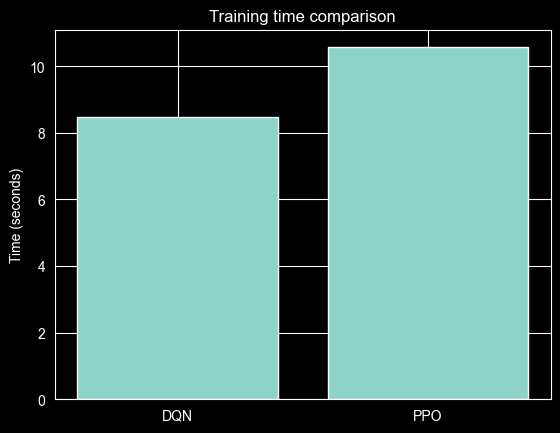

In [13]:
plt.bar(["DQN", "PPO"], [dqn_training_time, ppo_training_time])
plt.ylabel("Time (seconds)")
plt.title("Training time comparison")
plt.show()

## Average reward comparison

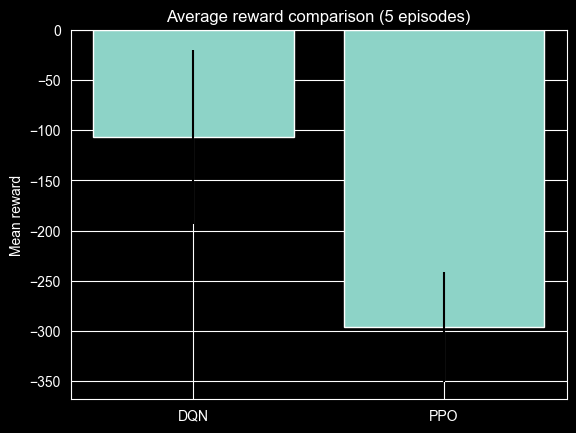

In [14]:
plt.bar(["DQN", "PPO"], [dqn_mean, ppo_mean], yerr=[dqn_std, ppo_std])
plt.ylabel("Mean reward")
plt.title("Average reward comparison (5 episodes)")
plt.show()

# Question 8

Using optimized hyperparameters from RL Baselines3 Zoo: https://github.com/DLR-RM/rl-baselines3-zoo

## DQN with optimized hyperparameters

In [15]:
env = gym.make("LunarLander-v3")

dqn_model_tuned = DQN(
    "MlpPolicy",
    env,
    learning_rate=6.3e-4,
    batch_size=128,
    buffer_size=50000,
    learning_starts=0,
    gamma=0.99,
    target_update_interval=250,
    train_freq=4,
    gradient_steps=-1,
    exploration_fraction=0.12,
    exploration_final_eps=0.1,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1
)

start_time = time.time()
dqn_model_tuned.learn(total_timesteps=100000)
dqn_tuned_training_time = time.time() - start_time

print("DQN tuned training time:", dqn_tuned_training_time, "seconds")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.8     |
|    ep_rew_mean      | -120     |
|    exploration_rate | 0.971    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1648     |
|    time_elapsed     | 0        |
|    total_timesteps  | 387      |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 0.951    |
|    n_updates        | 384      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.4     |
|    ep_rew_mean      | -117     |
|    exploration_rate | 0.942    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1659     |
|    time_elapsed     | 0        |
|    total_timesteps  | 779      |
| train/              |        

## PPO with optimized hyperparameters

In [16]:
env = gym.make("LunarLander-v3")

ppo_model_tuned = PPO(
    "MlpPolicy",
    env,
    n_steps=1024,
    batch_size=64,
    gae_lambda=0.98,
    gamma=0.999,
    n_epochs=4,
    ent_coef=0.01,
    verbose=1
)

start_time = time.time()
ppo_model_tuned.learn(total_timesteps=100000)
ppo_tuned_training_time = time.time() - start_time

print("PPO tuned training time:", ppo_tuned_training_time, "seconds")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89       |
|    ep_rew_mean     | -168     |
| time/              |          |
|    fps             | 9347     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 85.2          |
|    ep_rew_mean          | -150          |
| time/                   |               |
|    fps                  | 7792          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00056608644 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2       

## Evaluate tuned agents for 5 episodes

In [17]:
env = gym.make("LunarLander-v3")

dqn_tuned_mean, dqn_tuned_std = evaluate_policy(dqn_model_tuned, env, n_eval_episodes=5)
print("DQN tuned - Mean reward:", dqn_tuned_mean, "Std:", dqn_tuned_std)

ppo_tuned_mean, ppo_tuned_std = evaluate_policy(ppo_model_tuned, env, n_eval_episodes=5)
print("PPO tuned - Mean reward:", ppo_tuned_mean, "Std:", ppo_tuned_std)

DQN tuned - Mean reward: 21.75064544830915 Std: 263.87421650375495
PPO tuned - Mean reward: -329.0479525872623 Std: 126.33155571189263


## Training time comparison (tuned)

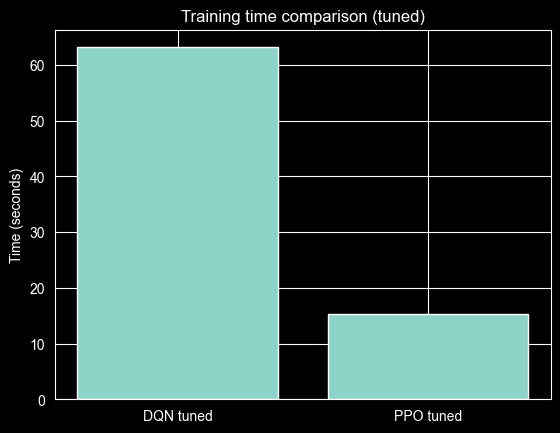

In [18]:
plt.bar(["DQN tuned", "PPO tuned"], [dqn_tuned_training_time, ppo_tuned_training_time])
plt.ylabel("Time (seconds)")
plt.title("Training time comparison (tuned)")
plt.show()

## Average reward comparison (tuned)

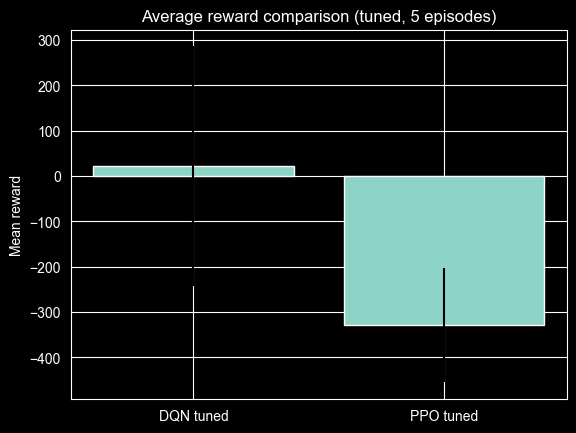

In [19]:
plt.bar(["DQN tuned", "PPO tuned"], [dqn_tuned_mean, ppo_tuned_mean], yerr=[dqn_tuned_std, ppo_tuned_std])
plt.ylabel("Mean reward")
plt.title("Average reward comparison (tuned, 5 episodes)")
plt.show()

## Watch trained agents

In [20]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = RecordVideo(env, "./output_dqn", episode_trigger=lambda x: True)

obs, info = env.reset()

while True:
    action, _ = dqn_model_tuned.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()

/Users/thanasisxan/repos/AI-101-Machine-Learning/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/thanasisxan/repos/AI-101-Machine-Learning/Exercise-9/output_dqn folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [21]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = RecordVideo(env, "./output_ppo", episode_trigger=lambda x: True)

obs, info = env.reset()

while True:
    action, _ = ppo_model_tuned.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break

env.close()

/Users/thanasisxan/repos/AI-101-Machine-Learning/.venv/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/thanasisxan/repos/AI-101-Machine-Learning/Exercise-9/output_ppo folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
